In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA

In [12]:
# Gather data and merge the wines together
df1 = pd.read_csv("winequality-white.csv", sep=";")
df2 = pd.read_csv("winequality-red.csv",   sep=";")
df1["color"] = "white"
df2["color"] = "red"
df = pd.concat([df1, df2], axis=0, ignore_index=True)
y = df['color']
X = df.drop(['color'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_np = X_train_scaled.values if hasattr(X_train_scaled, "values") else X_train_scaled
y_train_np = y_train.values      if hasattr(y_train,     "values") else y_train
y_train_np = y_train_np.ravel()
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# DBSCAN clustering
db = DBSCAN(eps=0.8, min_samples=10)
db_labels = db.fit_predict(X_scaled)

# K-Means clustering (K=2)
km = KMeans(n_clusters=2, random_state=42)
km_labels = km.fit_predict(X_scaled)

# DBSCAN vs. K-Means on Wine PCA Embedding

The figure shows two side-by-side scatter plots of the PCA‐reduced wine dataset:

- **Left**: DBSCAN cluster labels (`–1` = noise, `0,1,…` = core clusters)  
- **Right**: K-Means labels (two clusters, forced partition)

---

## 1. DBSCAN Findings

- **Dominant Core**  
  Almost every point falls into a single large dense cluster (label 0), indicating that both red and white wines share a high‐density region in feature space.
- **Outliers & Small Clusters**  
  A handful of points near the fringes received distinct cluster IDs or were marked as noise (`–1`). These likely correspond to unusual chemical profiles (e.g. extreme acidity or alcohol content).
- **No Red/White Separation**  
  Because DBSCAN groups by **density** rather than by class, it did **not** split the main cloud into two “red vs. white” clusters. The two wine types overlap too much in PCA space for DBSCAN (with the chosen `eps=0.8`, `min_samples=10`) to treat them as separate high‐density regions.

## 2. K-Means Findings

- **Two Balanced Clusters**  
  K-Means cleanly partitions the data into two roughly equal‐sized groups (cyan vs. navy), regardless of actual density.  
- **Alignment with Wine Color**  
  The boundary between the two centroids (right panel) aligns well with the known red/white split—most white wines fall to the left of the boundary, most reds to the right.

---

## 3. Comparative Insights

| Aspect           | DBSCAN                                    | K-Means                             |
|------------------|--------------------------------------------|-------------------------------------|
| Cluster Shape    | Arbitrary, density‐based                   | Spherical, centroid‐based           |
| Noise Handling   | Identifies outliers explicitly             | Assigns every point to a cluster    |
| Number of Clusters | Determined by density (here → 1 major + outliers) | Predefined as \(K=2\)               |
| Suitability Here | **Poor** for red/white separation; detects only one dense region | **Good** at recovering the binary wine types |

---

## 4. Next Steps

1. **Tune DBSCAN**  
   - Increase `eps` to merge small fringe clusters into two dense regions.  
   - Decrease `min_samples` to allow sparser clusters to form.  
2. **Evaluate Quantitatively**  
   - Compare clustering labels against true “red”/“white” using adjusted Rand index or purity.  
3. **Alternative Methods**  
   - Try spectral clustering or Gaussian Mixture Models, which can capture overlapping distributions more flexibly than DBSCAN.

---

**Conclusion:**  
With the current parameters, DBSCAN identifies one main cluster plus outliers and does not distinguish red vs. white wines. K-Means, by forcing exactly two groups, more faithfully recovers the known wine categories in the PCA‐reduced space.  

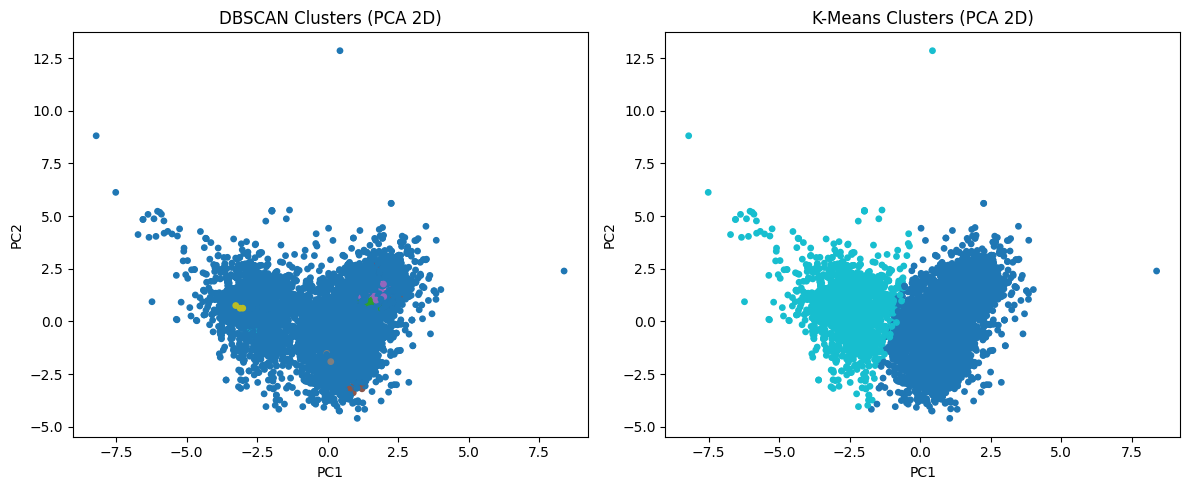

In [14]:
# Compare the clustering
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.scatter(X_pca[:,0], X_pca[:,1], c=db_labels, cmap='tab10', s=15)
ax1.set_title("DBSCAN Clusters (PCA 2D)")
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2")

ax2.scatter(X_pca[:,0], X_pca[:,1], c=km_labels, cmap='tab10', s=15)
ax2.set_title("K-Means Clusters (PCA 2D)")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")

plt.tight_layout()
plt.show()